## COMP5328 - Advanced Machine Learning
## Assignment 1: Non-negative Matrix Factorization
----------------------------------------------------------------------------------------


The submitted Jupyter notebook is intended to be run sequentially in one pass from start to finish. There should be no need to re-run previous cells, and doing so will also result in strange/inconsistent outputs as certain cells in the notebook will overwrite variable values from previous cells.

By default, the notebook assumes the ORL and YaleB datasets are located in a mounted Google Drive directory - this is because Google Colab was used to host the notebook and facilitate simultaneous contributions.

If the datasets are stored locally, the user can skip running the first 2 code cells. They will still need to run the 3rd code cell in order to initialise the function to load the datasets. Additionally, they will need to manually change the path to the ORL and YaleB datasets before calling the `load\_dataset()' function in the 4th code cell. Following this, no additional changes to the notebook will need to be made.

The following Python libraries were utilised:
- google (v2.0.3) - used to mount Google Drive
- os (built-in) - used to check file structure of the dataset directory, already present in default template
- math (built-in) - used for a single ceiling function call during a calculation
- numpy (v2.0.2) - used for array data structures, already present in default template
- PIL (v11.3.0) - used to load image data, already present in default template
- matplotlib (v3.10.0) - used to plot/draw images, already present in default template
- Collections (built-in) - used to create a Counter object, already present in default template
- sklearn.cluster (1.6.1) - used to perform clustering, already present in default template
- sklearn.metrics (1.6.1) - used to evaluate clustering performance, already present in default template

All of the NMF algorithm implementations have been completed using base Python and some numpy linear algebra and basic mathematical functions.

## 1. Load Dataset

### 1.0 Data Folder

The following functions display how to load the data and the output of the data. This may be different for the marker running the program, since we decided to store the datasets in our google drive and load the data from there. To adjust for data path changes, use a different root

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# The structure of data folder.
!ls -l drive/MyDrive/data

# Output should be as follows

'''
total 8
drwx------ 2 root root 4096 #DATE# CroppedYaleB
drwx------ 2 root root 4096 #DATE# ORL
'''

total 8
drwx------ 2 root root 4096 Sep 25 04:45 CroppedYaleB
drwx------ 2 root root 4096 Sep 25 04:45 ORL


'\ntotal 8\ndrwx------ 2 root root 4096 #DATE# CroppedYaleB\ndrwx------ 2 root root 4096 #DATE# ORL\n'

In [ ]:
import os
import numpy as np
from PIL import Image

def load_data(root='drive/MyDrive/data/CroppedYaleB', reduce=4):
    """
    Load ORL (or Extended YaleB) dataset to numpy array.

    Args:
        root: path to dataset.
        reduce: scale factor for zooming out images.

    """
    images, labels = [], []

    for i, person in enumerate(sorted(os.listdir(root))):

        if not os.path.isdir(os.path.join(root, person)):
            continue

        for fname in os.listdir(os.path.join(root, person)):

            # Remove background images in Extended YaleB dataset.
            if fname.endswith('Ambient.pgm'):
                continue

            if not fname.endswith('.pgm'):
                continue

            # load image.
            #img = Image.open(os.path.join(root, person, fname))
            with Image.open(os.path.join(root, person, fname)) as img:

              img = img.convert('L') # grey image.

              # reduce computation complexity.
              img = img.resize([s//reduce for s in img.size])

              # TODO: preprocessing.

              # convert image to numpy array.
              arr = np.asarray(img).reshape((-1,1))

              # collect data and label.
              images.append(arr)
              labels.append(i)

    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)

    return images, labels

In [ ]:
# Load ORL dataset.
orlX, orlY = load_data(root='drive/MyDrive/data/ORL', reduce=2)
print('ORL: X.shape = {}, Y.shape = {}'.format(orlX.shape, orlY.shape))

# Load Extended YaleB dataset.
ybX, ybY = load_data(root='drive/MyDrive/data/CroppedYaleB', reduce=4)
print('Extended YaleB dataset: X.shape = {}, Y.shape = {}'.format(ybX.shape, ybY.shape))

ORL: X.shape = (2576, 400), Y.shape = (400,)
Extended YaleB dataset: X.shape = (2016, 2428), Y.shape = (2428,)


# ORL Dataset

## Noise Implementation

In [ ]:
#different implementations of noise based on type
def add_noise(images, noise_type="salt_pepper", p=0.1, r=0.5, mean=0.0, std=0.05):
    noisy = images.copy()
    num_pixels, num_imgs = noisy.shape

    if noise_type == "salt_pepper":
        total_pixels = num_pixels * num_imgs
        num_noisy = int(p * total_pixels)
        idx = np.random.choice(total_pixels, num_noisy, replace=False)
        white_pixels = int(r * num_noisy)

        noisy_flat = noisy.flatten()
        noisy_flat[idx[:white_pixels]] = 1.0  # salt
        noisy_flat[idx[white_pixels:]] = 0.0  # pepper
        noisy = noisy_flat.reshape(noisy.shape)

    elif noise_type == "gaussian":
        noisy += np.random.normal(mean, std, noisy.shape)
        noisy = np.clip(noisy, 0.0, 1.0)

    elif noise_type == "speckle":
        noise = np.random.normal(0, std, noisy.shape)
        noisy += noisy * noise
        noisy = np.clip(noisy, 0.0, 1.0)

    elif noise_type == "poisson":
        noisy = np.random.poisson(noisy * 255.0) / 255.0
        noisy = np.clip(noisy, 0.0, 1.0)

    else:
        raise ValueError(f"Unknown noise_type: {noise_type}")

    return noisy

The following funciton displays the effect of various noises in the ORL dataset. As explained in the report however, we will only be utilising the salt and pepper noise.

ORL: (2576, 400)


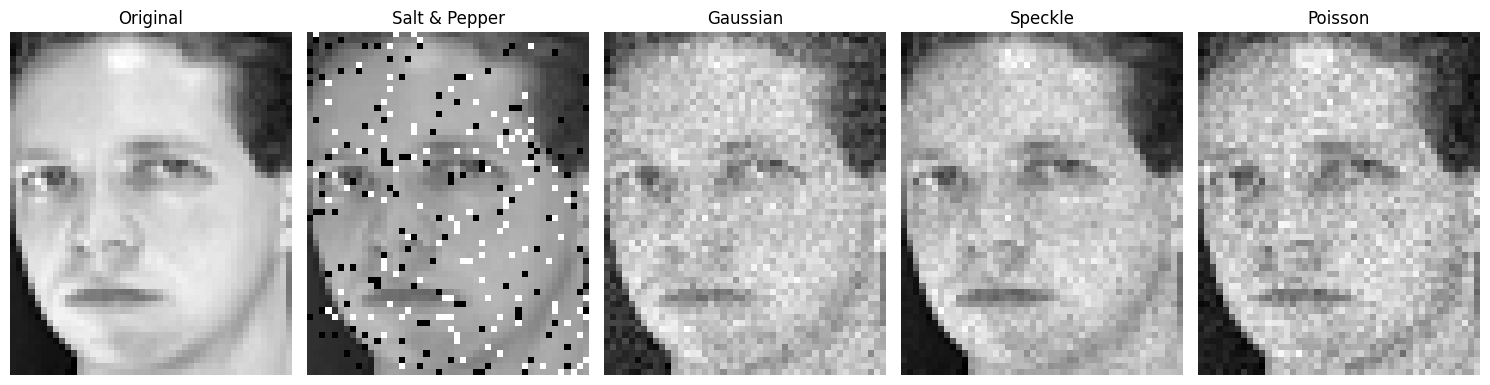

In [ ]:
import matplotlib.pyplot as plt

V_orl, y_orl = orlX, orlY
print("ORL:", V_orl.shape)
V_orl = V_orl.astype(np.float32) / 255.0
V_sp = add_noise(V_orl, noise_type="salt_pepper", p=0.1, r=0.5)
V_gauss = add_noise(V_orl, noise_type="gaussian", mean=0, std=0.05)
V_speckle = add_noise(V_orl, noise_type="speckle", std=0.05)
V_poisson = add_noise(V_orl, noise_type="poisson")

idx = 0
# Calculate img_height and img_width from the loaded data shape
img_height = int(np.sqrt(V_orl.shape[0] / (92/112))) # Assuming aspect ratio of 92/112
img_width = V_orl.shape[0] // img_height

img_original = V_orl[:, idx].reshape(img_height, img_width)
img_sp = V_sp[:, idx].reshape(img_height, img_width)
img_gauss = V_gauss[:, idx].reshape(img_height, img_width)
img_speckle = V_speckle[:, idx].reshape(img_height, img_width)
img_poisson = V_poisson[:, idx].reshape(img_height, img_width)

# Plot side by side
fig, axes = plt.subplots(1, 5, figsize=(15,5))
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(img_sp, cmap='gray')
axes[1].set_title("Salt & Pepper")
axes[2].imshow(img_gauss, cmap='gray')
axes[2].set_title("Gaussian")
axes[3].imshow(img_speckle, cmap='gray')
axes[3].set_title("Speckle")
axes[4].imshow(img_poisson, cmap='gray')
axes[4].set_title("Poisson")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## L1-Norm Based NMF Draft

In [ ]:
#the following function was designed to implement the l1 nmf on the ORL dataset
def l1_nmf(V, rank=20, max_iter=500, eta=1e-6, tol=1e-6, verbose=False):
    m, n = V.shape
    W = np.random.rand(m, rank) * 0.01
    H = np.random.rand(rank, n) * 0.01
    losses = []

    for it in range(max_iter+1):
        WH = W @ H
        loss = np.sum(np.abs(V - WH))
        losses.append(loss)

        if verbose and it % 50 == 0:
            print(f"Iter {it}, L1 loss: {loss:.6f}")

        grad = np.sign(WH - V)
        H -= eta * W.T @ grad
        W -= eta * grad @ H.T

        W = np.clip(W, 0, None)
        H = np.clip(H, 0, None)

        W /= np.maximum(np.linalg.norm(W, axis=0, keepdims=True), 1e-10)
        H /= np.maximum(np.linalg.norm(H, axis=1, keepdims=True), 1e-10)

        if it > 0 and abs(losses[-2] - losses[-1]) < tol:
          if verbose:
            print(f"Final Iter {it}, L1 loss: {loss:.6f}")
          break

    return W, H, losses

Without Noise
Iter 0, L1 loss: 454085.095034
Iter 50, L1 loss: 414523.098900
Iter 100, L1 loss: 414523.098614
Iter 150, L1 loss: 414523.098594
Iter 200, L1 loss: 414523.098900
Iter 250, L1 loss: 414523.098614
Iter 300, L1 loss: 414523.098594
Iter 350, L1 loss: 414523.098900
Iter 400, L1 loss: 414523.098614
Iter 450, L1 loss: 414523.098594
Iter 500, L1 loss: 414523.098900
RMSE: 0.4457916323338925


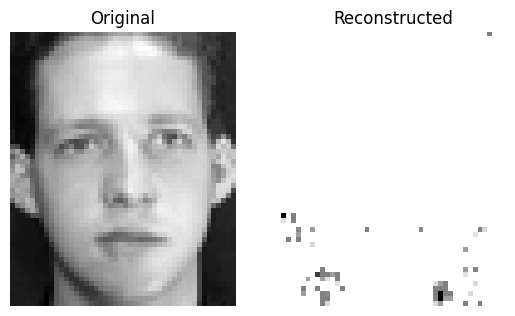

With Noise
Iter 0, L1 loss: 460227.412885
Iter 50, L1 loss: 424593.507254
Iter 100, L1 loss: 424593.507212
Iter 150, L1 loss: 424593.507163
Iter 200, L1 loss: 424593.507254
Iter 250, L1 loss: 424593.507212
Iter 300, L1 loss: 424593.507163
Iter 350, L1 loss: 424593.507254
Iter 400, L1 loss: 424593.507212
Iter 450, L1 loss: 424593.507163
Iter 500, L1 loss: 424593.507254
RMSE: 0.47444332877408546


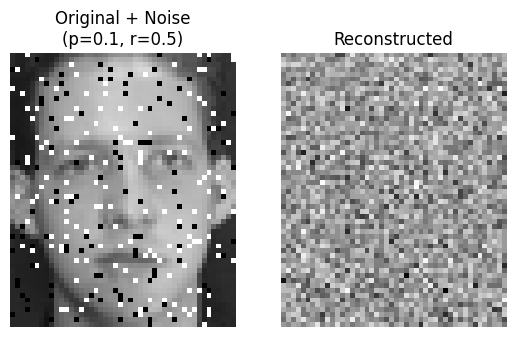

In [ ]:
import matplotlib.pyplot as plt

# Bad implementation draft of L1, did not use for evaluation
# The L1 implementation used for evaluation is under YaleB section
print("Without Noise")
rank = 40
W_l1, H_l1, losses = l1_nmf(V_orl, rank=rank, max_iter=500, eta=0.001, verbose=True)
V_reconstructed = W_l1 @ H_l1
rmse = np.sqrt(np.mean((V_orl - V_reconstructed)**2))
print("RMSE:", rmse)

plt.subplot(1,2,1); plt.imshow(V_orl[:,2].reshape(112//2,92//2), cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(V_reconstructed[:,2].reshape(112//2,92//2), cmap='gray'); plt.title("Reconstructed"); plt.axis('off')
plt.show()

print("With Noise")
rank = 40
W_l1, H_l1, losses = l1_nmf(V_sp, rank=rank, max_iter=500, eta=0.001, verbose=True)
V_reconstructed = W_l1 @ H_l1
rmse = np.sqrt(np.mean((V_sp - V_reconstructed)**2))
print("RMSE:", rmse)

plt.subplot(1,2,1); plt.imshow(V_sp[:,2].reshape(112//2,92//2), cmap='gray'); plt.title("Original + Noise\n(p=0.1, r=0.5)"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(V_reconstructed[:,2].reshape(112//2,92//2), cmap='gray'); plt.title("Reconstructed"); plt.axis('off')
plt.show()

##Hyber-Cauchy loss NMF

In [ ]:
#implementation of a Huyber-Cuchy loss in the ORL dataset, did not have time to fully evaluate
def hc_nmf(V, rank, max_iter, eta, tol=1e-6, verbose=False):
    m, n = V.shape
    W = np.random.rand(m, rank) * 0.01
    H = np.random.rand(rank, n) * 0.01
    losses = []

    for it in range(max_iter+1):
        WH = W @ H
        residual = V - WH
        loss = np.sum(residual*2 / (1 + residual*2))
        losses.append(loss)

        if verbose and it % 50 == 0:
            print(f"Iter {it}, HC loss: {loss:.6f}")

        # Compute gradient
        grad_factor = -2 * residual / (1 + residual*2)*2
        grad_H = W.T @ grad_factor
        grad_W = grad_factor @ H.T

        # Gradient descent update
        H -= eta * grad_H
        W -= eta * grad_W

        # Ensure non-negativity
        H = np.clip(H, 0, None)
        W = np.clip(W, 0, None)

        # normalization
        W /= np.maximum(np.linalg.norm(W, axis=0, keepdims=True), 1e-10)
        H /= np.maximum(np.linalg.norm(H, axis=1, keepdims=True), 1e-10)

        # Convergence check
        if it > 0 and abs(losses[-2] - losses[-1]) < tol:
          if verbose:
            print(f"Final Iter {it}, HC loss: {loss:.6f}")
          break

    return W, H, losses

Without Noise
Iter 0, HC loss: 457905.922982
Final Iter 34, HC loss: 433206.996972
RMSE: 0.44429125938504377


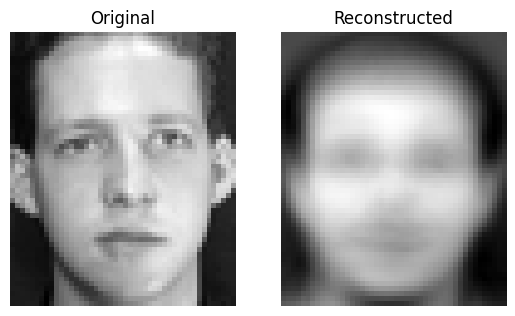

With Noise
Iter 0, HC loss: 446351.253320
Final Iter 34, HC loss: 419278.011500
RMSE: 0.47328273635314694


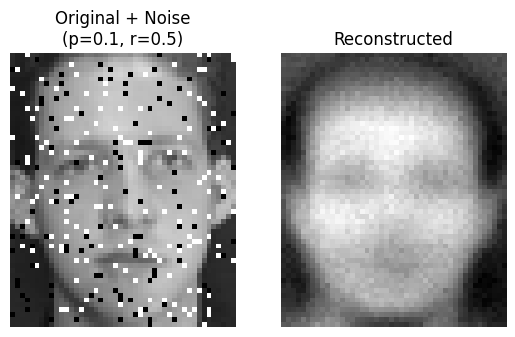

In [ ]:
import matplotlib.pyplot as plt

print("Without Noise")
rank = 40
W_hc, H_hc, losses = hc_nmf(V_orl, rank=rank, max_iter=500, eta=0.001, verbose=True)
V_reconstructed = W_hc @ H_hc
rmse = np.sqrt(np.mean((V_orl - V_reconstructed)**2))
print("RMSE:", rmse)

plt.subplot(1,2,1); plt.imshow(V_orl[:,2].reshape(112//2,92//2), cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(V_reconstructed[:,2].reshape(112//2,92//2), cmap='gray'); plt.title("Reconstructed"); plt.axis('off')
plt.show()

print("With Noise")
rank = 40
W_hc, H_hc, losses = hc_nmf(V_sp, rank=rank, max_iter=500, eta=0.001, verbose=True)
V_reconstructed = W_hc @ H_hc
rmse = np.sqrt(np.mean((V_sp - V_reconstructed)**2))
print("RMSE:", rmse)

plt.subplot(1,2,1); plt.imshow(V_sp[:,2].reshape(112//2,92//2), cmap='gray'); plt.title("Original + Noise\n(p=0.1, r=0.5)"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(V_reconstructed[:,2].reshape(112//2,92//2), cmap='gray'); plt.title("Reconstructed"); plt.axis('off')
plt.show()

# YALE B Dataset

The following is code for running and implementing the NMFs of the YaleB dataset.

## Basic NMF

In [ ]:
#objective function = MIN_D^R || X- DR||_F^2
#With the special functions that All elements in D and R are positive
#Optimisation Method: Multiplicative Update Rules

#Args:
#            n_components: Number of latent factors (rank k in factorization V ≈ WH)
#            max_iter: Maximum number of iterations
#            tol: Convergence tolerance (stops when cost change < tol)
#            random_state: Random seed for reproducible results

#let the random seed be 0
def initialise_matricies(n_components, X, random_state=0):
  np.random.seed(random_state)
  m, n = X.shape
  scale_factor = np.sqrt(np.mean(X) / n_components)
  D = np.random.rand(m, n_components) * scale_factor
  R = np.random.rand(n_components, n) * scale_factor
  return D, R

#function utilises multiplicative update rules
def updateR(D, R, X, eps=1e-10):
  numerator = D.T.dot(X)
  denominator = D.T.dot(D).dot(R)
  R_new = R * (numerator + eps) / (denominator + eps)
  R_new = np.maximum(R_new, 0)
  return R_new

def updateD(D, R, X, eps=1e-10):
  numerator = X.dot(R.T)
  denominator = D.dot(R).dot(R.T)
  D_new = D * (numerator + eps) / (denominator + eps)
  D_new = np.maximum(D_new, 0)
  return D_new

def nmf_fit(X, n_components, iterations=1000, tolerance=1e-6, random_state=0):
  D, R = initialise_matricies(n_components, X, random_state)
  history = []
  for i in range(iterations):
      R = updateR(D, R, X)
      D = updateD(D, R, X)
      reconstruction = D.dot(R)
      cost = np.linalg.norm(X - reconstruction, 'fro')**2
      history.append(cost)
      if i > 0:
          cost_change = np.abs(history[-1] - history[-2])
          if cost_change < tolerance:
              print(f"Basic NMF converged after {i + 1} iterations")
              break

  return D, R, history


##L1-Norm Based NMF Algorithm

In [ ]:
#Optimisation method: majorisation minimisation algorithmn
#Objective Function: min_{W, H} ||V - W H||_1 = sum_{i,j} |V_{ij} - (W H)_{ij}|
#Args:
#            n_components: Number of latent factors (rank k in factorization V ≈ WH)
#            max_iter: Maximum number of iterations
#            tol: Convergence tolerance (stops when cost change < tol)
#            random_state: Random seed for reproducible results

def l1_initialise_matricies(n_components, X, random_state):
  np.random.seed(random_state)
  m, n = X.shape
  scale_factor = np.sqrt(np.mean(X) / n_components)
  W = np.random.rand(m, n_components) * scale_factor
  H = np.random.rand(n_components, n) * scale_factor
  return W, H

def l1_update_H(W, H, V, WH, eps=1e-8):
  residual = V - WH
  weights = 1/np.sqrt((residual**2) + eps**2)
  numerator = W.T.dot(weights * V)
  denominator = W.T.dot(weights * WH)
  H_new = H * (numerator + 1e-10) / (denominator + 1e-10)
  return H_new

def l1_update_W(W, H, V, eps=1e-8):
  WH = W.dot(H)
  residual = V - WH
  weights = 1/np.sqrt((residual**2) + eps**2)
  numerator = (weights * V).dot(H.T)
  denominator = (weights * WH).dot(H.T)
  W_new = W * (numerator + 1e-10) / (denominator + 1e-10)
  return W_new

def l1_nmf_fit(X, n_components, iterations, tolerance, random_state, eps=1e-8):
  W, H = l1_initialise_matricies(n_components, X, random_state)
  history = []

  reconstruction = W.dot(H)
  for i in range(iterations):
      H = l1_update_H(W, H, X, reconstruction, eps)
      W = l1_update_W(W, H, X, eps)
      reconstruction = W.dot(H)
      cost = np.sum(np.sqrt((X - reconstruction)**2 + eps**2))
      history.append(cost)
      if i > 0:
          cost_change = np.abs(history[-1] - history[-2])
          if cost_change < tolerance:
              print(f"L1-NMF converged after {i + 1} iterations")
              break

  return W, H, history

##L2-1 Norm Based NMF

In [ ]:
#Objective Function: min_{A, Y} ||X - A Y||_{2,1} + λ ||Y||_{2,1}
#Optimization Method: Majorization-Minimization (MM) Algorithm, with emphasis on minimisation

def l2_initialise_matricies(n_components, V, random_state):
  np.random.seed(random_state)
  m, n = V.shape
  scale_factor = np.sqrt(np.mean(V) / n_components)
  W = np.random.rand(m, n_components) * scale_factor
  H = np.random.rand(n_components, n) * scale_factor
  return W, H

def l2_norm(X, epsilon=1e-8):
  row_norms = np.sqrt(np.sum(X**2, axis=1) + epsilon)
  return np.sum(row_norms)

def l2_compute_weights(res):
  row_norms = np.sqrt(np.sum(res**2, axis=1, keepdims=True) + 1e-10)
  return 1.0 / row_norms

def l2_update_H(W, H, V, WH):
  res = V - WH
  weights = l2_compute_weights(res)
  numerator = W.T.dot(weights * V)
  denominator = W.T.dot(weights * WH)
  H_new = H * (numerator + 1e-10) / (denominator + 1e-10)
  return H_new

def l2_update_W(W, H, V):
  WH = W.dot(H)
  res = V - WH
  weights = l2_compute_weights(res)
  numerator = (weights * V).dot(H.T)
  denominator = (weights * WH).dot(H.T)
  W_new = W * (numerator + 1e-10) / (denominator + 1e-10)
  return W_new

def l2_nmf_fit(X, n_components, iterations, tolerance, random_state):
  W, H = l2_initialise_matricies(n_components, X, random_state)
  history = []
  reconstruction = W.dot(H)
  for i in range(iterations):
    H = l2_update_H(W, H, X, reconstruction)
    W = l2_update_W(W, H, X)
    reconstruction = W.dot(H)
    res = X - reconstruction
    cost = l2_norm(res)
    history.append(float(cost))
    if i > 0:
      cost_change = np.abs(history[-1] - history[-2])
      if cost_change < tolerance:
        print(f"L2-1-NMF converged after {i + 1} iterations")
        break
  return W, H, history

Noise Implementation

In [ ]:
def add_salt_and_pepper_noise(V, p, r):
  np.random.seed(0)
  V_noise = V.copy()
  num_pixels = int(p * V.shape[0] * V.shape[1])
  noise_mask = np.random.rand(*V.shape) < p
  salt_and_pepper_mask = np.random.rand(*V.shape) < r
  V_noise[noise_mask & salt_and_pepper_mask] = 255
  V_noise[noise_mask & ~salt_and_pepper_mask] = 0
  return V_noise, noise_mask

def add_gaussian_noise(V, sig):
  np.random.seed(0)
  noise = np.random.normal(0, sig, V.shape)
  V_noise = V + noise
  V_noise = np.clip(V_noise, 0, 255)
  return V_noise

def add_uniform_noise(V, noise_level):
  np.random.seed(0)
  max_noise = 255 * noise_level
  noise = np.random.uniform(-max_noise, max_noise, V.shape)
  V_noise = V + noise
  V_noise = np.clip(V_noise, 0, 255)
  return V_noise


## Running YaleB dataset

The following illustrates the effect of different noises on the Yale B dataset. However, for reasons specified in the report, we will only utilise salt and pepper noise.

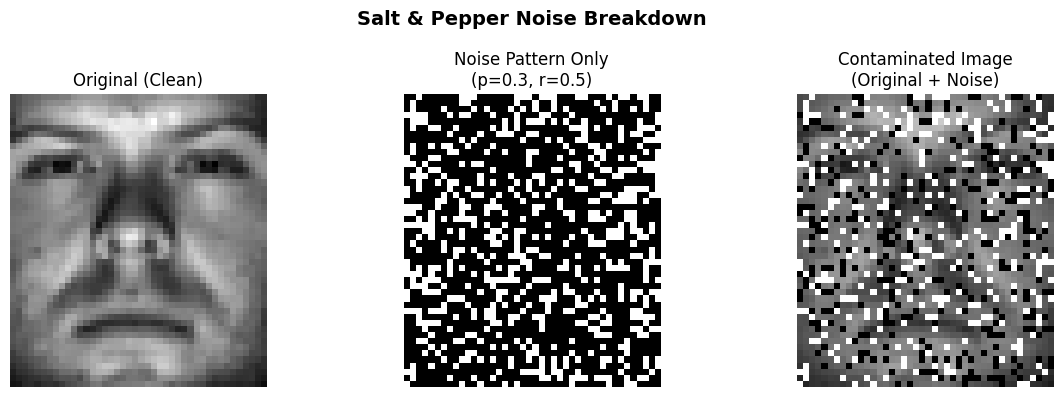

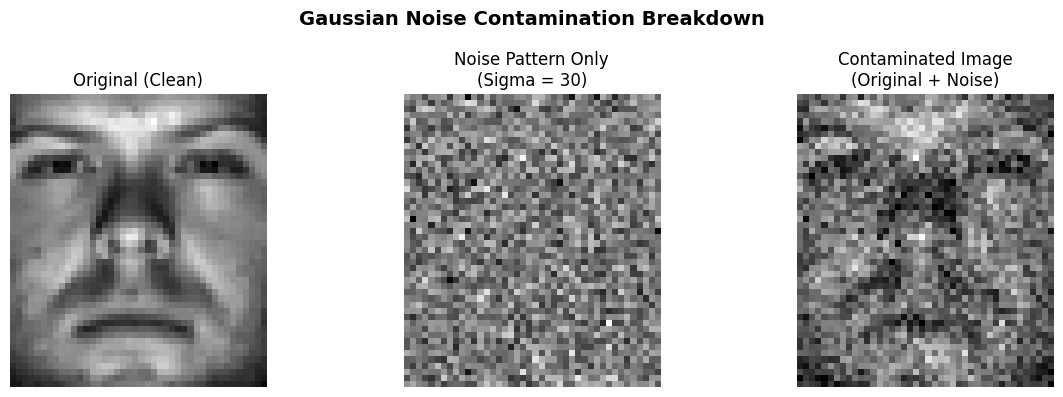

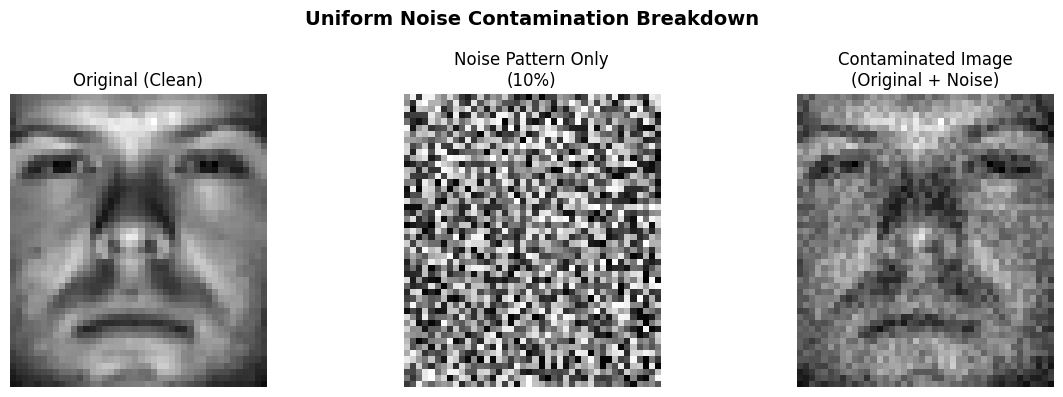

In [ ]:
import matplotlib.pyplot as plt

p = 0.3
r = 0.5
sigma = 30
noise_level = 0.1
img_idx = 2

# Load and prepare data
V_hat, Y_hat = ybX, ybY

# Calculate image size
original_size = (192, 168)
reduce_factor = 4
img_size = [original_size[1] // reduce_factor, original_size[0] // reduce_factor]

V_min, V_max = V_hat.min(), V_hat.max()
V_clean = ((V_hat - V_min) / (V_max - V_min)) * 255.0

# Set number of components
n_components = len(set(Y_hat))

V_noise_sap, noise_mask = add_salt_and_pepper_noise(V_clean, p, r)
V_gaussian = add_gaussian_noise(V_clean, sigma)
V_uniform = add_uniform_noise(V_clean, noise_level)

#salt and pepper

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(V_clean[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes2[0].set_title('Original (Clean)', fontsize=12)
axes2[0].axis('off')

V_noise_sap_only = V_noise_sap - V_clean
axes2[1].imshow(noise_mask[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes2[1].set_title(f'Noise Pattern Only\n(p={p}, r={r})', fontsize=12)
axes2[1].axis('off')

axes2[2].imshow(V_noise_sap[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes2[2].set_title('Contaminated Image\n(Original + Noise)', fontsize=12)
axes2[2].axis('off')

plt.suptitle('Salt & Pepper Noise Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#gaussian

fig, axes1 = plt.subplots(1, 3, figsize=(12, 4))

axes1[0].imshow(V_clean[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes1[0].set_title('Original (Clean)', fontsize=12)
axes1[0].axis('off')

V_gaussian_noise_only = V_gaussian - V_clean
axes1[1].imshow(V_gaussian_noise_only[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes1[1].set_title(f'Noise Pattern Only\n(Sigma = {30})', fontsize=12)
axes1[1].axis('off')

axes1[2].imshow(V_gaussian[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes1[2].set_title('Contaminated Image\n(Original + Noise)', fontsize=12)
axes1[2].axis('off')

plt.suptitle('Gaussian Noise Contamination Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#uniform noise

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(V_clean[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes[0].set_title('Original (Clean)', fontsize=12)
axes[0].axis('off')

V_uniform_noise_only = V_uniform - V_clean
axes[1].imshow(V_uniform_noise_only[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes[1].set_title(f'Noise Pattern Only\n({int(noise_level*100)}%)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(V_uniform[:, img_idx].reshape(img_size[1], img_size[0]), cmap='gray')
axes[2].set_title('Contaminated Image\n(Original + Noise)', fontsize=12)
axes[2].axis('off')

plt.suptitle('Uniform Noise Contamination Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




# 2. Evaluation Metrics


## Relative Reconstruction Errors (RRE)

To compare the robustness of different NMF algorithms, you can use the ```relative reconstruction errors```. Let $V$ denote the contaminated dataset (by adding noise), and $\hat{V}$
 denote the clean dataset. Let $W$ and $H$ denote the factorization results on $V$, the ``relative reconstruction errors`` then can be defined as follows:
 \begin{equation}
    RRE = \frac{ \| \hat{V} - WH \|_F }{ \| \hat{V} \|_F}.
\end{equation}

## Evaluate Clustering Performance
### Accuracy
    
$$ Acc(Y, Y_{pred}) = \frac{1}{n}\sum\limits_{i=1}^n 1\{Y_{pred}(i) == Y(i)\}$$
        
### Normalized Mutual Information (NMI)

$$ NMI(Y, Y_{pred}) = \frac{2 * I(Y, Y_{pred})}{H(Y) + H(Y_{pred})} $$
    
   where $ I(\cdot,\cdot) $ is mutual information and $ H(\cdot) $ is entropy.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, normalized_mutual_info_score

def assign_cluster_label(Ht, Y_sub, n_clusters, km_random_state):
    """
    Ht: shape (n_samples, n_components) = H.T
    Y_sub: true labels for these samples (length n_samples)
    returns: predicted labels (length n_samples) aligned with Y_sub indices
    """
    km = KMeans(n_clusters=n_clusters, random_state=km_random_state).fit(Ht)
    labels = km.labels_
    Y_pred = np.zeros_like(labels)
    for cl in np.unique(labels):
        idx = labels == cl
        if np.sum(idx) == 0:
            Y_pred[idx] = -1
        else:
            Y_pred[idx] = Counter(Y_sub[idx]).most_common(1)[0][0]
    return Y_pred

# helper to show example images
def plot_reconstructed_image(V_clean_all, V_noisy_full, recon_full, noise_mask_full, p, r,
                             original_size, img_indices, reduce_factor=4, vmax=255.0):
    """
    V_clean_all, V_noisy_full, recon_full: (m x n) arrays (m = pixels)
    img_indices: list of column indices to display (if None, choose index 2)
    original_size: (height, width) of original images before reduction, YaleB=(192,168); ORL = (112,92)
    reduce_factor: integer down-sampling factor used in loader
    vmax: maximum pixel value for display (default 255)
    """
    m, n = V_clean_all.shape

    if isinstance(img_indices, int):
      img_indices = [img_indices]
    # clamp indices
    img_indices = [min(max(0, int(i)), n-1) for i in img_indices]

    # compute height/width after reduction (height, width)
    height = original_size[0] // reduce_factor
    width  = original_size[1] // reduce_factor

    num = len(img_indices)
    fig, axs = plt.subplots(num, 3, figsize=(3*3, num*3))
    if num == 1:
        axs = axs.reshape(1,3)

    for row, col_idx in enumerate(img_indices):
        orig = V_clean_all[:, col_idx].reshape(height, width)
        #noiseimg = noise_mask_full[:, col_idx].reshape(height, width)
        noisy = V_noisy_full[:, col_idx].reshape(height, width)
        recon = recon_full[:, col_idx].reshape(height, width)

        # Original
        ax = axs[row, 0];ax.imshow(orig, cmap='gray', vmin=0, vmax=vmax);ax.set_title(f'Original');ax.axis('off')

        # Noise pattern
        # ax = axs[row, 1]; ax.imshow(noiseimg, cmap='gray'); ax.set_title(f'Noise Pattern Only\n(p={p}, r={r})'); ax.axis('off')

        # Noisy image
        ax = axs[row, 1]; ax.imshow(noisy, cmap='gray', vmin=0, vmax=vmax); ax.set_title(f'Image + Noise\n(p={p}, r={r})'); ax.axis('off')

        # Reconstructed
        ax = axs[row, 2]; ax.imshow(recon, cmap='gray', vmin=0, vmax=vmax); ax.set_title('Reconstructed'); ax.axis('off')

    plt.tight_layout()
    plt.show()

def evaluate_nmf(algorithm_str,V_clean_all,Y_all,noise_settings,original_size,img_graph_idx=2,reduce_factor=4,sample_frac=0.9,trials=5,iterations=200,tolerance=1e-6,random_state=0,verbose=True):
    """
    Run repeated random-subsample experiments on the YaleB dataset for a single algorithm.

    algorithm_str: "basic", "l1", or "l2"
    V_clean_all: clean data matrix (m x n)
    Y_all: labels array length n
    noise_settings: list of (p,r) tuples for salt & pepper
    sample_frac: fraction of columns to sample each trial (0 < sample_frac <= 1)
    trials: number of random trials per noise setting
    iterations, tolerance: forwarded to NMF solver
    random_state: RNG seed for sampling and KMeans base
    verbose: print per-trial and per-noise summaries
    """
    rng = np.random.RandomState(random_state)
    n_total = V_clean_all.shape[1]
    n_components = len(set(Y_all))

    # results container
    all_results = {}

    # Validate algorithm string
    alg = algorithm_str.lower()
    if alg not in ('basic', 'l1', 'l2'):
        print("algorithm must be one of 'basic', 'l1', or 'l2'")
        return

    for (p, r) in noise_settings:
        if verbose:
            print("\n" + "="*60)
            print(f"Algorithm: {alg.upper()} | Noise setting p={p}, r={r}")

        # create noisy dataset once per (p,r)
        V_noisy_full, noise_mask = add_salt_and_pepper_noise(V_clean_all, p=p, r=r)
        V_noisy_full = V_noisy_full.astype(np.float64)
        V_clean_all_f = V_clean_all.astype(np.float64)

        rre_list, acc_list, nmi_list = [], [], []

        for t in range(trials):
            # sample columns; if sample_frac==1 take all columns (preserve original order)
            if sample_frac >= 1.0:
                idx = np.arange(n_total)
            else:
              # sample 90% columns without replacement
              n_sample = int(math.ceil(sample_frac * n_total))
              idx = rng.choice(n_total, size=n_sample, replace=False)

            Vn = V_noisy_full[:, idx]
            Vc = V_clean_all_f[:, idx]
            Y_sub = Y_all[idx]

            # Choose and call the requested NMF algorithm directly
            if alg == 'basic':
                # nmf_fit(X, n_components, iterations=..., tolerance=..., random_state=0)
                W, H, history = nmf_fit(Vn, n_components=n_components, iterations=iterations, tolerance=tolerance, random_state=random_state)
            elif alg == 'l1':
                # l1_nmf_fit(X, n_components, iterations, tolerance, random_state, eps=1e-8)
                W, H, history = l1_nmf_fit(Vn, n_components=n_components, iterations=iterations, tolerance=tolerance, random_state=random_state, eps=1e-8)
                #W, H, history = l1_nmf(Vn, rank= n_components, max_iter=500, eta=1e-6, tol=1e-6, verbose=True)
            elif alg == 'l2':  # 'l2'
                # l2_nmf_fit(X, n_components, iterations, tolerance)
                W, H, history = l2_nmf_fit(Vn, n_components=n_components, iterations=iterations, tolerance=tolerance, random_state= random_state)

            # Metrics
            rre_val = np.linalg.norm(Vc - W.dot(H)) / np.linalg.norm(Vc)
            Ht = H.T
            Y_pred = assign_cluster_label(Ht, Y_sub, n_clusters=n_components, km_random_state=random_state + t)
            acc_val = accuracy_score(Y_sub, Y_pred)
            nmi_val = normalized_mutual_info_score(Y_sub, Y_pred)

            rre_list.append(rre_val)
            acc_list.append(acc_val)
            nmi_list.append(nmi_val)

            # If this is a single full-data run, then plot
            if verbose and trials == 1 and sample_frac >= 1.0:
                # recon_full corresponds to the full dataset when idx is all columns
                recon_full = W.dot(H)
                # Plot reconstructed image (use V_clean_all and V_noisy_full)
                plot_reconstructed_image(V_clean_all, V_noisy_full, recon_full, noise_mask, p, r, original_size, img_graph_idx, reduce_factor)

            if verbose:
              if trials >1:
                print(f" Trial {t+1}/{trials} -> RRE: {rre_val:.4f} | Acc: {acc_val:.4f} | NMI: {nmi_val:.4f}")

        # summarize
        results = {
            'p': p, 'r': r,
            'RRE_list': rre_list, 'RRE_mean': float(np.mean(rre_list)), 'RRE_std': float(np.std(rre_list)),
            'Acc_list': acc_list, 'Acc_mean': float(np.mean(acc_list)), 'Acc_std': float(np.std(acc_list)),
            'NMI_list': nmi_list, 'NMI_mean': float(np.mean(nmi_list)), 'NMI_std': float(np.std(nmi_list))
        }
        all_results[(p, r)] = results

        if verbose:
          if trials >1:
            print(f"\nSummary (p={p}, r={r}): RRE = {results['RRE_mean']:.4f} ± {results['RRE_std']:.4f} | "
                  f"Acc = {results['Acc_mean']:.4f} ± {results['Acc_std']:.4f} | NMI = {results['NMI_mean']:.4f} ± {results['NMI_std']:.4f}")
          else:
            print(f"\nResult (p={p}, r={r}): RRE = {rre_val:.4f} | Acc = {acc_val:.4f} | NMI = {nmi_val:.4f}")

    return all_results


#### Evaluate metrics (RRE / Accuracy / NMI) for Basic (Multiplicative Update) NMF on ORL with salt & pepper noise

This code below runs the Basic (Multiplicative Update) NMF algorithm on the ORL dataset for four salt-and-pepper settings (p,r) and computes three evaluation metrics: Relative Reconstruction Error (RRE), clustering Accuracy (**Acc**), and Normalized Mutual Information (NMI). For the printed results we run on the full dataset with no repeat.

Loading ORL dataset...
Loaded: V_hat.shape=(2576, 400), Y_hat.shape=(400,), #classes=40

Run Multiplicative Update NMF on all images in ORL dataset (No repeat, No random sampling)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: BASIC | Noise setting p=0.2, r=0.1


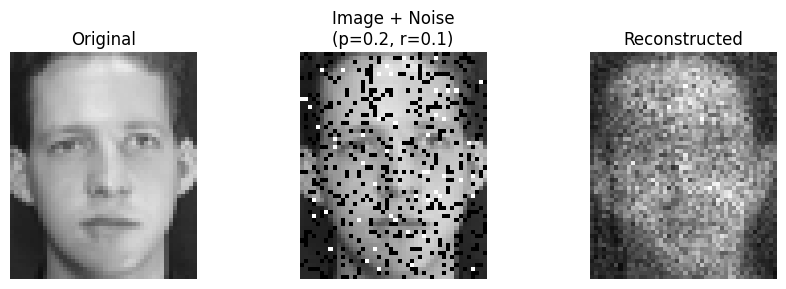


Result (p=0.2, r=0.1): RRE = 0.2646 | Acc = 0.5850 | NMI = 0.7607

Algorithm: BASIC | Noise setting p=0.2, r=0.7


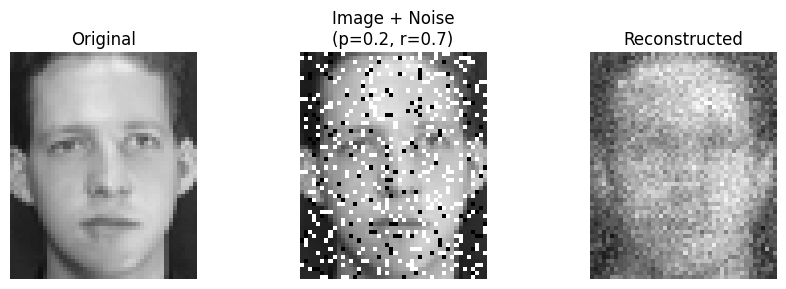


Result (p=0.2, r=0.7): RRE = 0.2511 | Acc = 0.5825 | NMI = 0.7448

Algorithm: BASIC | Noise setting p=0.4, r=0.1


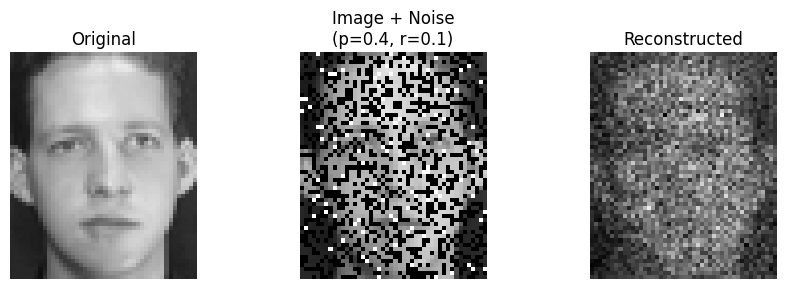


Result (p=0.4, r=0.1): RRE = 0.4103 | Acc = 0.4100 | NMI = 0.5876

Algorithm: BASIC | Noise setting p=0.4, r=0.7


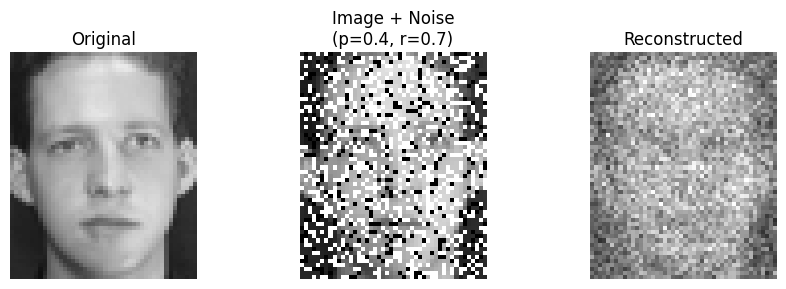


Result (p=0.4, r=0.7): RRE = 0.3686 | Acc = 0.3125 | NMI = 0.4891


In [ ]:
# === load ORL ===
print("Loading ORL dataset...")
V_hat, Y_hat = orlX, orlY
print(f"Loaded: V_hat.shape={V_hat.shape}, Y_hat.shape={Y_hat.shape}, #classes={len(set(Y_hat))}\n")

# Normalize to 0-255
V_min, V_max = V_hat.min(), V_hat.max()
V_clean_all = ((V_hat - V_min) / (V_max - V_min)) * 255.0

# --- configuration ---
noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

print("Run Multiplicative Update NMF on all images in ORL dataset (No repeat, No random sampling)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")
# Then call:
results = evaluate_nmf(
    algorithm_str='basic',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(112,92), # YaleB=(192,168); ORL = (112,92)
    img_graph_idx=2,
    reduce_factor=2, # YaleB=4 , ORL=2, not needed if no graph
    sample_frac=1, # Randomly sampling x% of data
    trials=1, # repeat n times
    iterations=500,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

To provide a more rigorous evaluation, we can repeat each noise pair (p,r) 5 times for each experiment by randomly sampling 90% data
from the whole ORL dataset, and average the metrics alongside the standard deviation:

In [ ]:
print("Run Multiplicative Update Based NMF on 90% images in ORL dataset (Repeat 5 times, Randomly sampling 90% data)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")

noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

# This takes about 2 minutes to run since each noise pair (p,r) is repeated 5 times
results = evaluate_nmf(
    algorithm_str='basic',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(112,92), # YaleB=(192,168); ORL = (112,92)
    sample_frac=0.9, # Randomly sampling x% of data
    trials=5, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

Run Multiplicative Update Based NMF on 90% images in ORL dataset (Repeat 5 times, Randomly sampling 90% data)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: BASIC | Noise setting p=0.2, r=0.1
 Trial 1/5 -> RRE: 0.2701 | Acc: 0.5667 | NMI: 0.7386
 Trial 2/5 -> RRE: 0.2705 | Acc: 0.5556 | NMI: 0.7344
 Trial 3/5 -> RRE: 0.2695 | Acc: 0.5389 | NMI: 0.7182
 Trial 4/5 -> RRE: 0.2695 | Acc: 0.5333 | NMI: 0.7165
 Trial 5/5 -> RRE: 0.2707 | Acc: 0.5528 | NMI: 0.7326

Summary (p=0.2, r=0.1): RRE = 0.2701 ± 0.0005 | Acc = 0.5494 ± 0.0120 | NMI = 0.7281 ± 0.0090

Algorithm: BASIC | Noise setting p=0.2, r=0.7
 Trial 1/5 -> RRE: 0.2573 | Acc: 0.5194 | NMI: 0.6886
 Trial 2/5 -> RRE: 0.2560 | Acc: 0.5583 | NMI: 0.7108
 Trial 3/5 -> RRE: 0.2583 | Acc: 0.5056 | NMI: 0.6856
 Trial 4/5 -> RRE: 0.2580 | Acc: 0.5250 | NMI: 0.7188
 Trial 5/5 -> RRE: 0.2581 | Acc: 0.5694 | NMI: 0.7096

Summary (p=0.2, r=0.7): RRE = 0.2575 ± 0.0009 | Acc = 0.5356 ± 0

#### Evaluate metrics (RRE / Accuracy / NMI) for Basic (Multiplicative Update) NMF on YaleB with salt & pepper noise

This code below runs the Basic (Multiplicative Update) NMF algorithm on the YaleB dataset for four salt-and-pepper settings (p,r) and computes three evaluation metrics: Relative Reconstruction Error (RRE), clustering Accuracy (**Acc**), and Normalized Mutual Information (NMI). For the printed results we run on the full dataset with no repeat.

Loading YaleB dataset...
Loaded: V_hat.shape=(2016, 2414), Y_hat.shape=(2414,), #classes=38

Run Multiplicative Update NMF on all images in YaleB dataset (No repeat, No random sampling)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: BASIC | Noise setting p=0.2, r=0.1


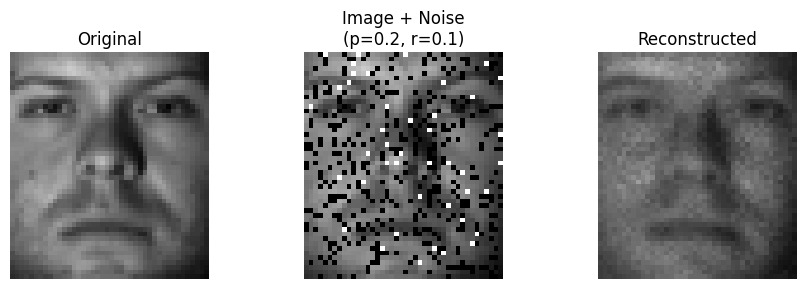


Result (p=0.2, r=0.1): RRE = 0.2681 | Acc = 0.1951 | NMI = 0.2595

Algorithm: BASIC | Noise setting p=0.2, r=0.7


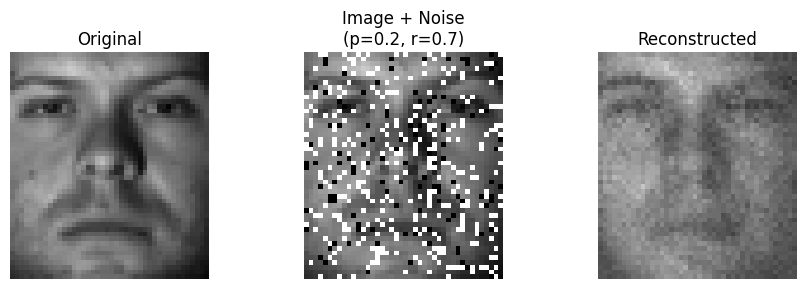


Result (p=0.2, r=0.7): RRE = 0.3642 | Acc = 0.1674 | NMI = 0.2229

Algorithm: BASIC | Noise setting p=0.4, r=0.1


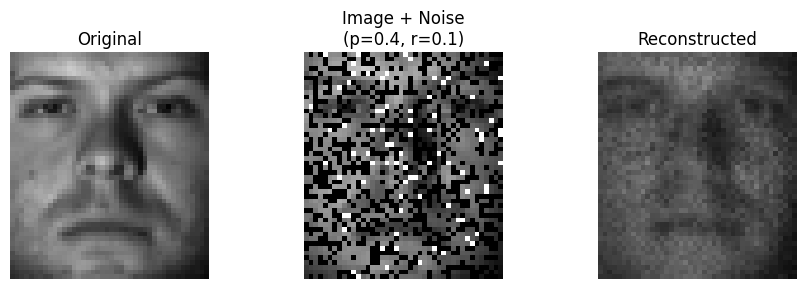


Result (p=0.4, r=0.1): RRE = 0.4002 | Acc = 0.1466 | NMI = 0.1765

Algorithm: BASIC | Noise setting p=0.4, r=0.7


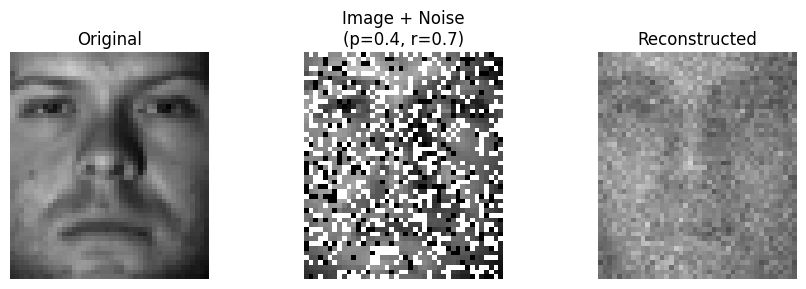


Result (p=0.4, r=0.7): RRE = 0.6178 | Acc = 0.1031 | NMI = 0.1107


In [ ]:
# === load YaleB ===
print("Loading YaleB dataset...")
V_hat, Y_hat = ybX, ybY
print(f"Loaded: V_hat.shape={V_hat.shape}, Y_hat.shape={Y_hat.shape}, #classes={len(set(Y_hat))}\n")

# Normalize to 0-255
V_min, V_max = V_hat.min(), V_hat.max()
V_clean_all = ((V_hat - V_min) / (V_max - V_min)) * 255.0

# --- configuration ---
noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

print("Run Multiplicative Update NMF on all images in YaleB dataset (No repeat, No random sampling)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")
# Then call:
results = evaluate_nmf(
    algorithm_str='basic',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(192,168), # YaleB=(192,168); ORL = (112,92)
    img_graph_idx=2,
    reduce_factor=4, # YaleB=4 , ORL=2, argument not needed if no graph
    sample_frac=1, # Randomly sampling x% of data
    trials=1, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

To provide a more rigorous evaluation, we can repeat each noise pair (p,r) 5 times for each experiment by randomly sampling 90% data
from the whole ORL dataset, and average the metrics alongside the standard deviation:

In [ ]:
print("Run Multiplicative Update Based NMF on 90% images in Extended YaleB dataset (Repeat 5 times, Randomly sampling 90% data)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")

noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

# This takes about 20 minutes to run since each noise pair (p,r) is repeated 5 times
results = evaluate_nmf(
    algorithm_str='basic',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(192,168), # YaleB=(192,168); ORL = (112,92)
    sample_frac=0.9, # Randomly sampling x% of data
    trials=5, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

Run Multiplicative Update Based NMF on 90% images in Extended YaleB dataset (Repeat 5 times, Randomly sampling 90% data)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: BASIC | Noise setting p=0.2, r=0.1
 Trial 1/5 -> RRE: 0.2690 | Acc: 0.2011 | NMI: 0.2680
 Trial 2/5 -> RRE: 0.2698 | Acc: 0.2112 | NMI: 0.2811
 Trial 3/5 -> RRE: 0.2677 | Acc: 0.1997 | NMI: 0.2681
 Trial 4/5 -> RRE: 0.2689 | Acc: 0.1979 | NMI: 0.2728
 Trial 5/5 -> RRE: 0.2676 | Acc: 0.1882 | NMI: 0.2644

Summary (p=0.2, r=0.1): RRE = 0.2686 ± 0.0008 | Acc = 0.1996 ± 0.0073 | NMI = 0.2709 ± 0.0058

Algorithm: BASIC | Noise setting p=0.2, r=0.7
 Trial 1/5 -> RRE: 0.3657 | Acc: 0.1680 | NMI: 0.2141
 Trial 2/5 -> RRE: 0.3655 | Acc: 0.1601 | NMI: 0.2176
 Trial 3/5 -> RRE: 0.3650 | Acc: 0.1523 | NMI: 0.2275
 Trial 4/5 -> RRE: 0.3669 | Acc: 0.1744 | NMI: 0.2462
 Trial 5/5 -> RRE: 0.3686 | Acc: 0.1523 | NMI: 0.2013

Summary (p=0.2, r=0.7): RRE = 0.3663 ± 0.0013 | Acc =

#### Evaluate metrics (RRE / Accuracy / NMI) for L1-NMF on ORL with salt & pepper noise

This code below runs the L1-NMF algorithm on the ORL dataset for four salt-and-pepper settings (p,r) and computes three evaluation metrics: Relative Reconstruction Error (RRE), clustering Accuracy (Acc), and Normalized Mutual Information (NMI). For the printed results we run on the full dataset with no repeat.

Loading ORL dataset...
Loaded: V_hat.shape=(2576, 400), Y_hat.shape=(400,), #classes=40

Run L1-Norm Based NMF on all images in ORL dataset (No repeat, No random sampling)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: L1 | Noise setting p=0.2, r=0.1


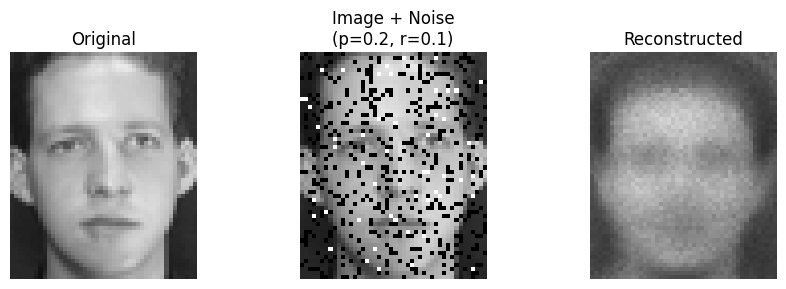


Result (p=0.2, r=0.1): RRE = 0.3133 | Acc = 0.1950 | NMI = 0.3607

Algorithm: L1 | Noise setting p=0.2, r=0.7


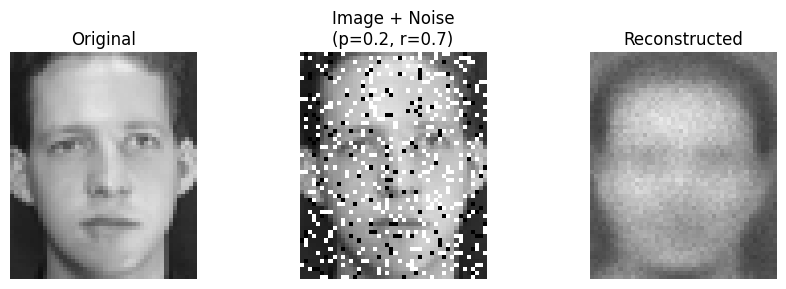


Result (p=0.2, r=0.7): RRE = 0.3067 | Acc = 0.2025 | NMI = 0.3637

Algorithm: L1 | Noise setting p=0.4, r=0.1


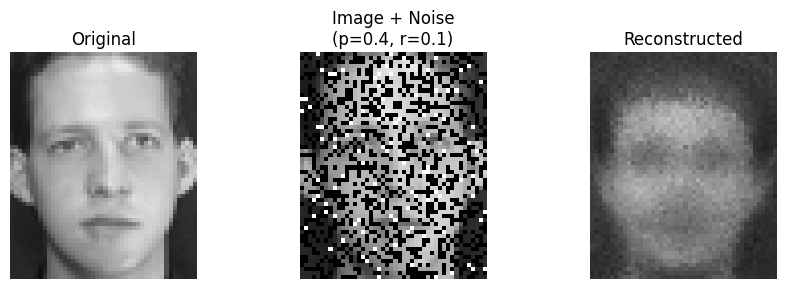


Result (p=0.4, r=0.1): RRE = 0.3865 | Acc = 0.2025 | NMI = 0.3753

Algorithm: L1 | Noise setting p=0.4, r=0.7


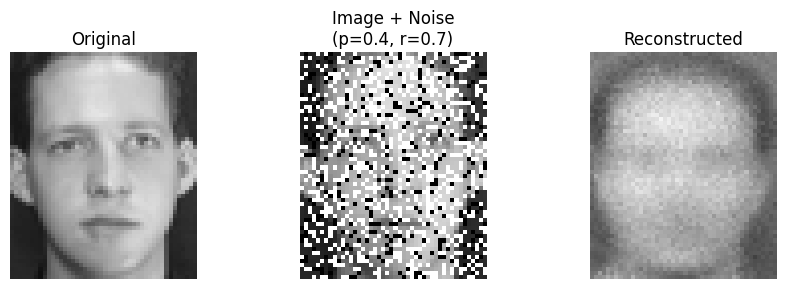


Result (p=0.4, r=0.7): RRE = 0.3260 | Acc = 0.1775 | NMI = 0.3385


In [ ]:
# === load ORL ===
print("Loading ORL dataset...")
V_hat, Y_hat = orlX, orlY
print(f"Loaded: V_hat.shape={V_hat.shape}, Y_hat.shape={Y_hat.shape}, #classes={len(set(Y_hat))}\n")

# Normalize to 0-255
V_min, V_max = V_hat.min(), V_hat.max()
V_clean_all = ((V_hat - V_min) / (V_max - V_min)) * 255.0

# --- configuration ---
noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

print("Run L1-Norm Based NMF on all images in ORL dataset (No repeat, No random sampling)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")
# Then call:
results = evaluate_nmf(
    algorithm_str='l1',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(112,92), # YaleB=(192,168); ORL = (112,92)
    img_graph_idx=2,
    reduce_factor=2, # YaleB=4 , ORL=2, not needed if no graph
    sample_frac=1, # Randomly sampling x% of data
    trials=1, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

To provide a more rigorous evaluation, we can repeat each noise pair (p,r) 5 times for each experiment by randomly sampling 90% data
from the whole ORL dataset, and average the metrics alongside the standard deviation:

In [ ]:
print("Run L1-Norm Based NMF on 90% images in ORL dataset (Repeat 5 times, Randomly sampling 90% data)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")

noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

# Each noise pair (p,r) is repeated 5 times, takes about 8 minutes to run
results = evaluate_nmf(
    algorithm_str='l1',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(112,92), # YaleB=(192,168); ORL = (112,92)
    sample_frac=0.9, # Randomly sampling x% of data
    trials=5, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

Run L1-Norm Based NMF on 90% images in ORL dataset (Repeat 5 times, Randomly sampling 90% data)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: L1 | Noise setting p=0.2, r=0.1
 Trial 1/5 -> RRE: 0.3156 | Acc: 0.1972 | NMI: 0.3973
 Trial 2/5 -> RRE: 0.3152 | Acc: 0.1972 | NMI: 0.3918
 Trial 3/5 -> RRE: 0.3136 | Acc: 0.1972 | NMI: 0.3714
 Trial 4/5 -> RRE: 0.3123 | Acc: 0.2000 | NMI: 0.3988
 Trial 5/5 -> RRE: 0.3138 | Acc: 0.1972 | NMI: 0.3878

Summary (p=0.2, r=0.1): RRE = 0.3141 ± 0.0012 | Acc = 0.1978 ± 0.0011 | NMI = 0.3894 ± 0.0098

Algorithm: L1 | Noise setting p=0.2, r=0.7
 Trial 1/5 -> RRE: 0.3072 | Acc: 0.1944 | NMI: 0.3809
 Trial 2/5 -> RRE: 0.3063 | Acc: 0.2000 | NMI: 0.4031
 Trial 3/5 -> RRE: 0.3055 | Acc: 0.2000 | NMI: 0.3772
 Trial 4/5 -> RRE: 0.3065 | Acc: 0.2083 | NMI: 0.3955
 Trial 5/5 -> RRE: 0.3062 | Acc: 0.1806 | NMI: 0.3566

Summary (p=0.2, r=0.7): RRE = 0.3064 ± 0.0005 | Acc = 0.1967 ± 0.0092 | NMI = 0.3827

#### Evaluate metrics (RRE / Accuracy / NMI) for L1-NMF on YaleB with salt & pepper noise

This code below runs the L1-NMF algorithm on the YaleB dataset for four salt-and-pepper settings (p,r) and computes three evaluation metrics: Relative Reconstruction Error (RRE), clustering Accuracy (Acc), and Normalized Mutual Information (NMI). For the printed results we run on the full dataset with no repeat.

Loading YaleB dataset...
Loaded: V_hat.shape=(2016, 2414), Y_hat.shape=(2414,), #classes=38

Run L1-Norm Based NMF on all images in ORL dataset (No repeat, No random sampling)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: L1 | Noise setting p=0.2, r=0.1


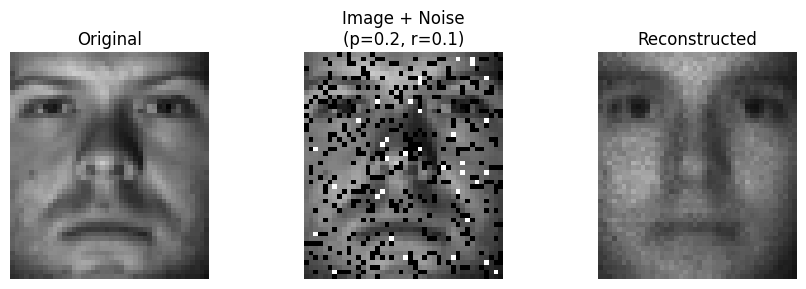


Result (p=0.2, r=0.1): RRE = 0.3580 | Acc = 0.0833 | NMI = 0.0834

Algorithm: L1 | Noise setting p=0.2, r=0.7


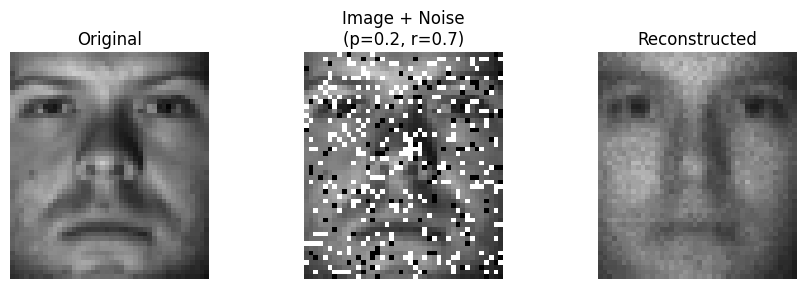


Result (p=0.2, r=0.7): RRE = 0.3325 | Acc = 0.0857 | NMI = 0.0814

Algorithm: L1 | Noise setting p=0.4, r=0.1


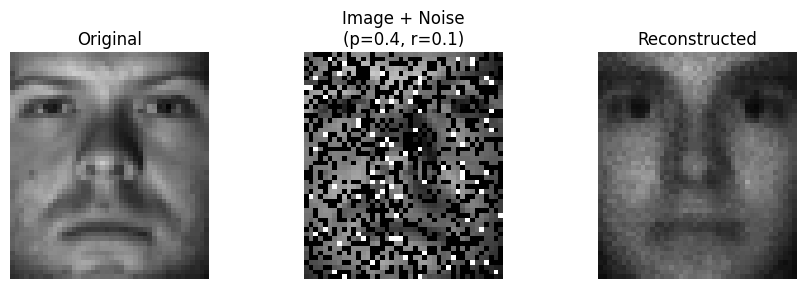


Result (p=0.4, r=0.1): RRE = 0.5400 | Acc = 0.0766 | NMI = 0.0725

Algorithm: L1 | Noise setting p=0.4, r=0.7


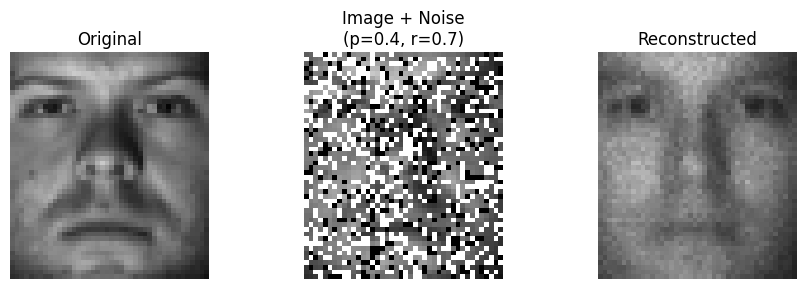


Result (p=0.4, r=0.7): RRE = 0.3502 | Acc = 0.0820 | NMI = 0.0758


In [ ]:
# === load YaleB ===
print("Loading YaleB dataset...")
V_hat, Y_hat = ybX, ybY
print(f"Loaded: V_hat.shape={V_hat.shape}, Y_hat.shape={Y_hat.shape}, #classes={len(set(Y_hat))}\n")

# Normalize to 0-255
V_min, V_max = V_hat.min(), V_hat.max()
V_clean_all = ((V_hat - V_min) / (V_max - V_min)) * 255.0

# --- configuration ---
noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

print("Run L1-Norm Based NMF on all images in ORL dataset (No repeat, No random sampling)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")
# Then call:
results = evaluate_nmf(
    algorithm_str='l1',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(192,168), # YaleB=(192,168); ORL = (112,92)
    img_graph_idx=0,
    reduce_factor=4, # YaleB=4 , ORL=2, not needed if no graph
    sample_frac=1, # Randomly sampling x% of data
    trials=1, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

To provide a more rigorous evaluation, we can repeat each noise pair (p,r) 5 times for each experiment by randomly sampling 90% data
from the whole ORL dataset, and average the metrics alongside the standard deviation:

In [ ]:
print("Run L1-Norm Based NMF on 90% images in Extended YaleB dataset (Repeat 5 times, Randomly sampling 90% data)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")

noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

# Each noise pair (p,r) is repeated 5 times, takes about 16 minutes to run
results = evaluate_nmf(
    algorithm_str='l1',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(192,168), # YaleB=(192,168); ORL = (112,92)
    sample_frac=0.9, # Randomly sampling x% of data
    trials=5, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

Run L1-Norm Based NMF on 90% images in Extended YaleB dataset (Repeat 5 times, Randomly sampling 90% data)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: L1 | Noise setting p=0.2, r=0.1
 Trial 1/5 -> RRE: 0.3429 | Acc: 0.0865 | NMI: 0.0850
 Trial 2/5 -> RRE: 0.3366 | Acc: 0.0819 | NMI: 0.0874
 Trial 3/5 -> RRE: 0.3351 | Acc: 0.0819 | NMI: 0.0843
 Trial 4/5 -> RRE: 0.3341 | Acc: 0.0815 | NMI: 0.0828
 Trial 5/5 -> RRE: 0.3393 | Acc: 0.0851 | NMI: 0.0874

Summary (p=0.2, r=0.1): RRE = 0.3376 ± 0.0032 | Acc = 0.0834 ± 0.0020 | NMI = 0.0854 ± 0.0018

Algorithm: L1 | Noise setting p=0.2, r=0.7
 Trial 1/5 -> RRE: 0.3161 | Acc: 0.0828 | NMI: 0.0869
 Trial 2/5 -> RRE: 0.3109 | Acc: 0.0819 | NMI: 0.0806
 Trial 3/5 -> RRE: 0.3117 | Acc: 0.0833 | NMI: 0.0851
 Trial 4/5 -> RRE: 0.3156 | Acc: 0.0810 | NMI: 0.0814
 Trial 5/5 -> RRE: 0.3126 | Acc: 0.0838 | NMI: 0.0795

Summary (p=0.2, r=0.7): RRE = 0.3134 ± 0.0021 | Acc = 0.0826 ± 0.0010 | N

#### Evaluate metrics (RRE / Accuracy / NMI) for L2,1-NMF on ORL with salt & pepper noise

This code below runs the L2,1-NMF algorithm on the ORL dataset for four salt-and-pepper settings (p,r) and computes three evaluation metrics: Relative Reconstruction Error (RRE), clustering Accuracy (Acc), and Normalized Mutual Information (NMI). For the printed results we run on the full dataset with no repeat.

Loading ORL dataset...
Loaded: V_hat.shape=(2576, 400), Y_hat.shape=(400,), #classes=40

Run L2,1-Norm Based NMF on all images in Extended YaleB dataset (No repeat, No random sampling)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: L2 | Noise setting p=0.2, r=0.1


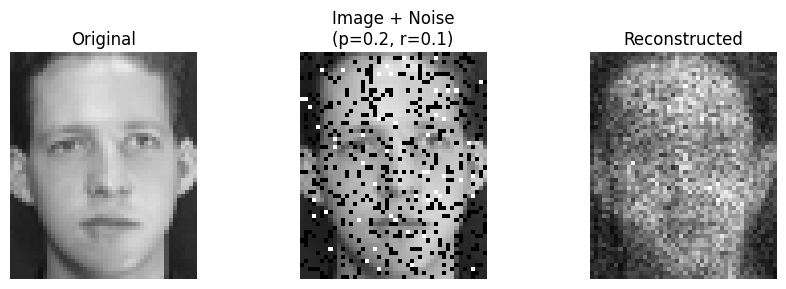


Result (p=0.2, r=0.1): RRE = 0.2636 | Acc = 0.6075 | NMI = 0.7745

Algorithm: L2 | Noise setting p=0.2, r=0.7


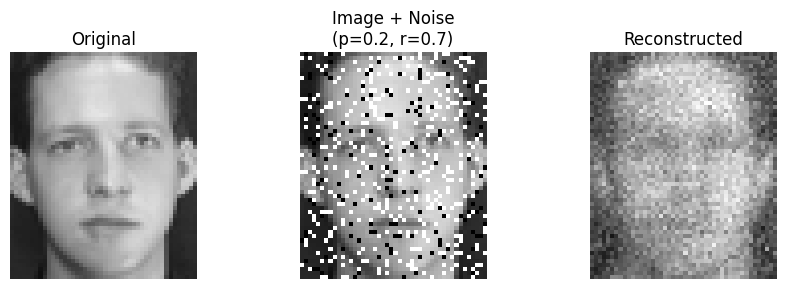


Result (p=0.2, r=0.7): RRE = 0.2507 | Acc = 0.6075 | NMI = 0.7486

Algorithm: L2 | Noise setting p=0.4, r=0.1


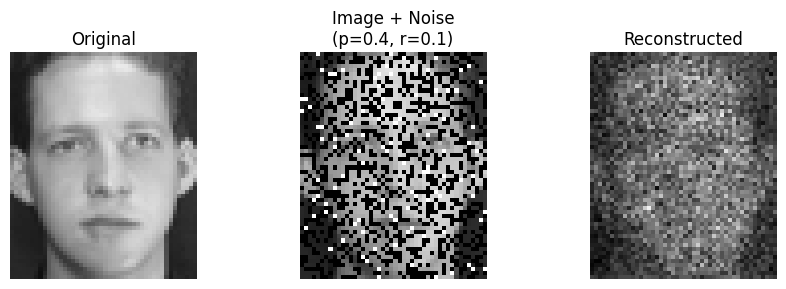


Result (p=0.4, r=0.1): RRE = 0.4098 | Acc = 0.4075 | NMI = 0.5872

Algorithm: L2 | Noise setting p=0.4, r=0.7


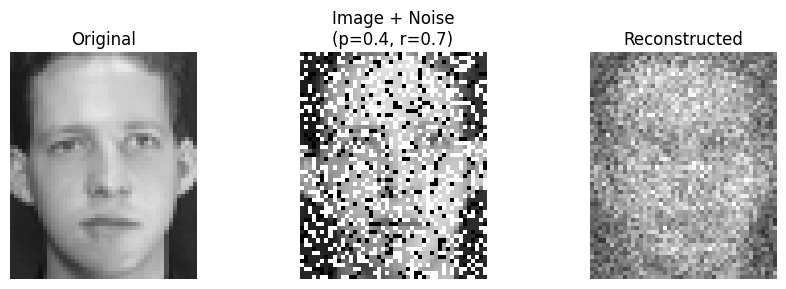


Result (p=0.4, r=0.7): RRE = 0.3682 | Acc = 0.3150 | NMI = 0.4886


In [ ]:
# === load ORL ===
print("Loading ORL dataset...")
V_hat, Y_hat = orlX, orlY
print(f"Loaded: V_hat.shape={V_hat.shape}, Y_hat.shape={Y_hat.shape}, #classes={len(set(Y_hat))}\n")

# Normalize to 0-255
V_min, V_max = V_hat.min(), V_hat.max()
V_clean_all = ((V_hat - V_min) / (V_max - V_min)) * 255.0

# --- configuration ---
noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

print("Run L2,1-Norm Based NMF on all images in Extended YaleB dataset (No repeat, No random sampling)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")
# Then call:
results = evaluate_nmf(
    algorithm_str='l2',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(112,92), # YaleB=(192,168); ORL = (112,92)
    img_graph_idx=2,
    reduce_factor=2, # YaleB=4 , ORL=2, not needed if no graph
    sample_frac=1, # Randomly sampling x% of data
    trials=1, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

To provide a more rigorous evaluation, we can repeat each noise pair (p,r) 5 times for each experiment by randomly sampling 90% data
from the whole ORL dataset, and average the metrics alongside the standard deviation:

In [ ]:
print("Run L2,1-Norm Based NMF on 90% images in ORL dataset (Repeat 5 times, Randomly sampling 90% data)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")

noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

# Each noise pair (p,r) is repeated 5 times, takes about 8 minutes to run
results = evaluate_nmf(
    algorithm_str='l2',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(112,92), # YaleB=(192,168); ORL = (112,92)
    sample_frac=0.9, # Randomly sampling x% of data
    trials=5, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

Run L2,1-Norm Based NMF on 90% images in ORL dataset (Repeat 5 times, Randomly sampling 90% data)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: L2 | Noise setting p=0.2, r=0.1
 Trial 1/5 -> RRE: 0.2683 | Acc: 0.5972 | NMI: 0.7573
 Trial 2/5 -> RRE: 0.2685 | Acc: 0.5806 | NMI: 0.7359
 Trial 3/5 -> RRE: 0.2672 | Acc: 0.5750 | NMI: 0.7428
 Trial 4/5 -> RRE: 0.2678 | Acc: 0.5778 | NMI: 0.7430
 Trial 5/5 -> RRE: 0.2691 | Acc: 0.5667 | NMI: 0.7520

Summary (p=0.2, r=0.1): RRE = 0.2682 ± 0.0006 | Acc = 0.5794 ± 0.0100 | NMI = 0.7462 ± 0.0076

Algorithm: L2 | Noise setting p=0.2, r=0.7
 Trial 1/5 -> RRE: 0.2558 | Acc: 0.5250 | NMI: 0.6982
 Trial 2/5 -> RRE: 0.2544 | Acc: 0.6111 | NMI: 0.7490
 Trial 3/5 -> RRE: 0.2568 | Acc: 0.5667 | NMI: 0.7227
 Trial 4/5 -> RRE: 0.2566 | Acc: 0.5389 | NMI: 0.7086
 Trial 5/5 -> RRE: 0.2570 | Acc: 0.5889 | NMI: 0.7398

Summary (p=0.2, r=0.7): RRE = 0.2561 ± 0.0009 | Acc = 0.5661 ± 0.0315 | NMI = 0.72

#### Evaluate metrics (RRE / Accuracy / NMI) for L2,1-NMF on YaleB with salt & pepper noise

This code below runs the L2,1-NMF algorithm on the Extended YaleB dataset for four salt-and-pepper settings (p,r) and computes three evaluation metrics: Relative Reconstruction Error (RRE), clustering Accuracy (Acc), and Normalized Mutual Information (NMI). For the printed results we run on the full dataset with no repeat.

Loading Extended YaleB dataset...
Loaded: V_hat.shape=(2016, 2414), Y_hat.shape=(2414,), #classes=38

Run L2,1-Norm Based NMF on all images in Extended YaleB dataset (No repeat, No random sampling)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: L2 | Noise setting p=0.2, r=0.1


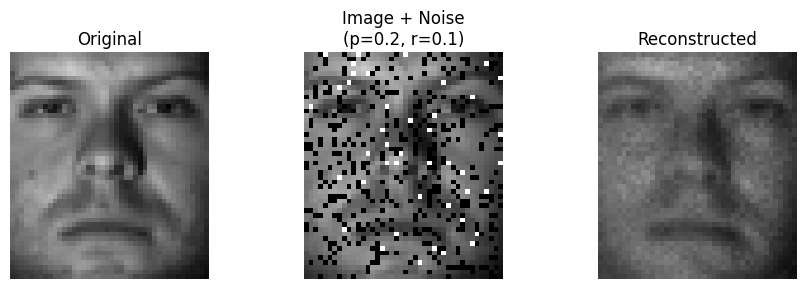


Result (p=0.2, r=0.1): RRE = 0.2679 | Acc = 0.2051 | NMI = 0.2814

Algorithm: L2 | Noise setting p=0.2, r=0.7


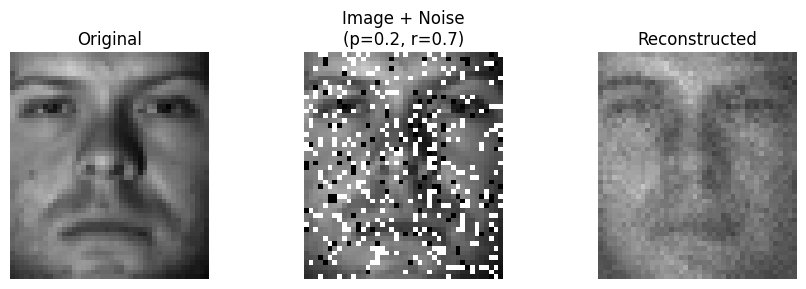


Result (p=0.2, r=0.7): RRE = 0.3642 | Acc = 0.1736 | NMI = 0.2294

Algorithm: L2 | Noise setting p=0.4, r=0.1


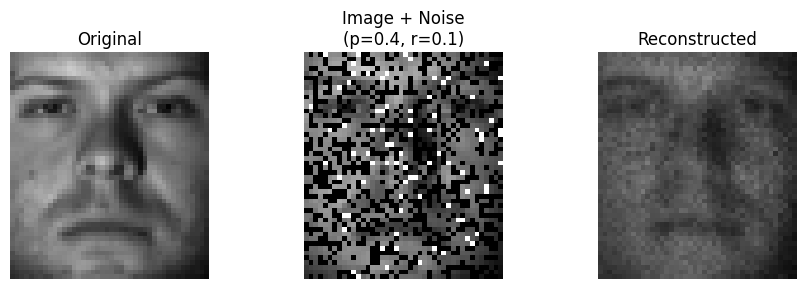


Result (p=0.4, r=0.1): RRE = 0.3994 | Acc = 0.1599 | NMI = 0.1943

Algorithm: L2 | Noise setting p=0.4, r=0.7


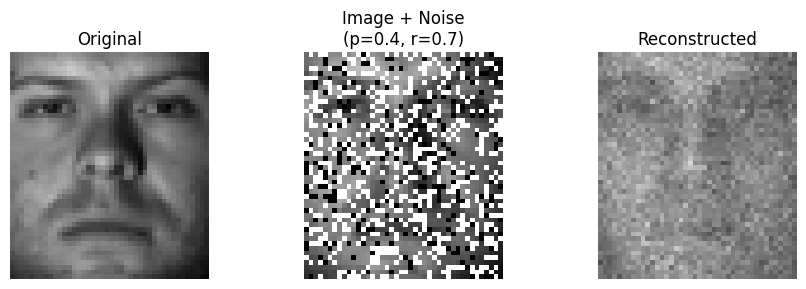


Result (p=0.4, r=0.7): RRE = 0.6178 | Acc = 0.0940 | NMI = 0.1093


In [ ]:
# === load YaleB ===
print("Loading Extended YaleB dataset...")
V_hat, Y_hat = ybX, ybY
print(f"Loaded: V_hat.shape={V_hat.shape}, Y_hat.shape={Y_hat.shape}, #classes={len(set(Y_hat))}\n")

# Normalize to 0-255
V_min, V_max = V_hat.min(), V_hat.max()
V_clean_all = ((V_hat - V_min) / (V_max - V_min)) * 255.0

# --- configuration ---
noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

print("Run L2,1-Norm Based NMF on all images in Extended YaleB dataset (No repeat, No random sampling)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")
# Then call:
results = evaluate_nmf(
    algorithm_str='l2',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(192,168), # YaleB=(192,168); ORL = (112,92)
    img_graph_idx=2,
    reduce_factor=4, # YaleB=4 , ORL=2, not needed if no graph
    sample_frac=1, # Randomly sampling x% of data
    trials=1, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

To provide a more rigorous evaluation, we can repeat each noise pair (p,r) 5 times for each experiment by randomly sampling 90% data
from the whole YaleB dataset, and average the metrics alongside the standard deviation:

In [ ]:
print("Run L2,1-Norm Based NMF on 90% images in Extended YaleB dataset (Repeat 3 times, Randomly sampling 90% data)")
print("Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}")

noise_settings = [
    (0.2, 0.1),
    (0.2, 0.7),
    (0.4, 0.1),
    (0.4, 0.7)
]

# This takes about 25 minutes to run since each noise pair (p,r) is repeated 5 times
results = evaluate_nmf(
    algorithm_str='l2',
    V_clean_all=V_clean_all,
    Y_all=Y_hat,
    noise_settings=noise_settings,
    original_size=(192,168), # YaleB=(192,168); ORL = (112,92)
    sample_frac=0.9, # Randomly sampling x% of data
    trials=5, # repeat n times
    iterations=200,
    tolerance=1e-6,
    random_state=0,
    verbose=True
)

Run L2,1-Norm Based NMF on 90% images in Extended YaleB dataset (Repeat 3 times, Randomly sampling 90% data)
Use salt and pepper noise with 4 pairs of (p,r) : {(0.2, 0.1);(0.2, 0.7);(0.4, 0.1);(0.4, 0.7)}

Algorithm: L2 | Noise setting p=0.2, r=0.1
 Trial 1/5 -> RRE: 0.2683 | Acc: 0.2108 | NMI: 0.2760
 Trial 2/5 -> RRE: 0.2689 | Acc: 0.2062 | NMI: 0.2666
 Trial 3/5 -> RRE: 0.2674 | Acc: 0.2043 | NMI: 0.2653
 Trial 4/5 -> RRE: 0.2686 | Acc: 0.1891 | NMI: 0.2700
 Trial 5/5 -> RRE: 0.2671 | Acc: 0.2029 | NMI: 0.2791

Summary (p=0.2, r=0.1): RRE = 0.2681 ± 0.0007 | Acc = 0.2027 ± 0.0073 | NMI = 0.2714 ± 0.0053

Algorithm: L2 | Noise setting p=0.2, r=0.7
 Trial 1/5 -> RRE: 0.3658 | Acc: 0.1795 | NMI: 0.2048
 Trial 2/5 -> RRE: 0.3654 | Acc: 0.1689 | NMI: 0.2243
 Trial 3/5 -> RRE: 0.3651 | Acc: 0.1698 | NMI: 0.2336
 Trial 4/5 -> RRE: 0.3670 | Acc: 0.1767 | NMI: 0.2398
 Trial 5/5 -> RRE: 0.3686 | Acc: 0.1629 | NMI: 0.2184

Summary (p=0.2, r=0.7): RRE = 0.3664 ± 0.0013 | Acc = 0.1716 ± 0.0059 |